- Add sampling to rollouts
- Check IRIS paper
- Do it with MPPI
- From continuous states?

In [1]:
import random

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

import numpy as np
from matplotlib import pyplot as plt    

import optax
import equinox as eqx 
from jax import Array, numpy as jnp, random as jr, nn

from qwen import QwenModel, utils, generate, forward

In [2]:
def load_dataset():
    loaded_data = np.load("data.npz")

    probs0 = loaded_data["probs0"]
    probs1 = loaded_data["probs1"]
    probs2 = loaded_data["probs2"]
    rewards = loaded_data["rewards"]
    actions = loaded_data["actions"]

    probs0_ids = jnp.argmax(probs0, axis=-1)
    probs1_ids = jnp.argmax(probs1, axis=-1)
    probs2_ids = jnp.argmax(probs2, axis=-1)
    reward_ids = jnp.argmax(rewards, axis=-1)
    action_ids = jnp.argmax(actions, axis=-1)

    N = action_ids.shape[0]
    split = int(0.9 * N)

    train_probs0, test_probs0 = probs0_ids[:split], probs0_ids[split:]
    train_probs1, test_probs1 = probs1_ids[:split], probs1_ids[split:]
    train_probs2, test_probs2 = probs2_ids[:split], probs2_ids[split:]
    train_rewards, test_rewards = reward_ids[:split], reward_ids[split:]
    train_actions, test_actions = action_ids[:split], action_ids[split:]

    return (
        train_probs0,
        train_probs1,
        train_probs2,
        train_rewards,
        train_actions,
        test_probs0,
        test_probs1,
        test_probs2,
        test_rewards,
        test_actions,
    )


def sample_sequences(
    key: jr.PRNGKey,
    obj1: jnp.ndarray,
    obj2: jnp.ndarray,
    obj3: jnp.ndarray,
    actions: jnp.ndarray,
    rewards: jnp.ndarray,
    seq_len: int,
    B: int,
):
    N = obj1.shape[0]
    key, subkey = jr.split(key)
    starts = jr.randint(subkey, (B,), minval=0, maxval=N - seq_len)

    batch_obj1 = jnp.stack([obj1[s : s + seq_len] for s in starts])
    batch_obj2 = jnp.stack([obj2[s : s + seq_len] for s in starts])
    batch_obj3 = jnp.stack([obj3[s : s + seq_len] for s in starts])
    batch_actions = jnp.stack([actions[s : s + seq_len] for s in starts])
    batch_rewards = jnp.stack([rewards[s : s + seq_len] for s in starts])

    return key, batch_obj1, batch_obj2, batch_obj3, batch_actions, batch_rewards

In [3]:
def train_model(
    model,
    train_probs0,
    train_probs1,
    train_probs2,
    train_rewards,
    train_actions,
    obj1_size,
    obj2_size,
    obj3_size,
    reward_size,
    seq_len,
    batch_size,
    callback,
    epochs,
    warmup_steps=2000,
    key=jr.PRNGKey(0),
):
    total_steps = epochs

    # schedule = optax.warmup_cosine_decay_schedule(
    #     init_value=0.0,
    #     peak_value=1e-4,
    #     warmup_steps=warmup_steps,
    #     decay_steps=total_steps,
    #     end_value=1e-6,
    # )
    schedule = 1e-4
    optimizer = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adamw(schedule, b1=0.9, b2=0.98, weight_decay=0.01),
    )
    opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

    def loss_fn(
        model,
        obj1_ids,
        obj2_ids,
        obj3_ids,
        action_ids,
        tgt_obj1,
        tgt_obj2,
        tgt_obj3,
        tgt_rewards,
    ):
        logits = forward(model, obj1_ids, obj2_ids, obj3_ids, action_ids)
        logits_obj1, logits_obj2, logits_obj3, logits_rewards = jnp.split(
            logits,
            [obj1_size, obj1_size + obj2_size, obj1_size + obj2_size + obj3_size],
            axis=-1,
        )
        loss_obj1 = optax.softmax_cross_entropy_with_integer_labels(
            logits_obj1, tgt_obj1
        )
        loss_obj2 = optax.softmax_cross_entropy_with_integer_labels(
            logits_obj2, tgt_obj2
        )
        loss_obj3 = optax.softmax_cross_entropy_with_integer_labels(
            logits_obj3, tgt_obj3
        )
        loss_rewards = optax.softmax_cross_entropy_with_integer_labels(
            logits_rewards, tgt_rewards
        )
        return (loss_obj1 + loss_obj2 + loss_obj3 + loss_rewards).mean()

    @eqx.filter_jit
    def step(
        model,
        opt_state,
        obj1_ids,
        obj2_ids,
        obj3_ids,
        action_ids,
        tgt_obj1,
        tgt_obj2,
        tgt_obj3,
        tgt_rewards,
    ):
        loss_value, grads = eqx.filter_value_and_grad(loss_fn)(
            model,
            obj1_ids,
            obj2_ids,
            obj3_ids,
            action_ids,
            tgt_obj1,
            tgt_obj2,
            tgt_obj3,
            tgt_rewards,
        )
        updates, opt_state = optimizer.update(grads, opt_state, model)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss_value

    for epoch in range(epochs):
        key, batch_obj1, batch_obj2, batch_obj3, batch_actions, batch_rewards = (
            sample_sequences(
                key,
                train_probs0,
                train_probs1,
                train_probs2,
                train_actions,
                train_rewards,
                seq_len,
                batch_size,
            )
        )

        inputs_obj1 = batch_obj1[:, :-1]
        targets_obj1 = batch_obj1[:, 1:]
        inputs_obj2 = batch_obj2[:, :-1]
        targets_obj2 = batch_obj2[:, 1:]
        inputs_obj3 = batch_obj3[:, :-1]
        targets_obj3 = batch_obj3[:, 1:]
        inputs_actions = batch_actions[:, :-1]
        targets_rewards = batch_rewards[:, 1:]

        model, opt_state, loss = step(
            model,
            opt_state,
            inputs_obj1,
            inputs_obj2,
            inputs_obj3,
            inputs_actions,
            targets_obj1,
            targets_obj2,
            targets_obj3,
            targets_rewards,
        )

        if epoch % 100 == 0:
            callback(model, loss)

    return model


def evaluate(
    model,
    test_obj1,
    test_obj2,
    test_obj3,
    test_actions,
    test_rewards,
    obj1_size,
    obj2_size,
    obj3_size,
    reward_size,
    context_len=64,
    max_tokens=64,
):
    start = random.randint(0, test_obj1.shape[0] - max_tokens - context_len)

    true_obj1_seq = test_obj1[start : start + context_len + max_tokens]
    true_obj2_seq = test_obj2[start : start + context_len + max_tokens]
    true_obj3_seq = test_obj3[start : start + context_len + max_tokens]
    true_action_seq = test_actions[start : start + context_len + max_tokens]
    true_reward_seq = test_rewards[start : start + context_len + max_tokens]

    context_obj1 = true_obj1_seq[:context_len]
    context_obj2 = true_obj2_seq[:context_len]
    context_obj3 = true_obj3_seq[:context_len]

    gen_obj1, gen_obj2, gen_obj3, gen_rewards = generate(
        model,
        obj1_tokens=jnp.array([context_obj1]),
        obj2_tokens=jnp.array([context_obj2]),
        obj3_tokens=jnp.array([context_obj3]),
        action_tokens=jnp.array([true_action_seq]),
        obj1_size=obj1_size,
        obj2_size=obj2_size,
        obj3_size=obj3_size,
        reward_size=reward_size,
        max_tokens=max_tokens,
    )

    gen_obj1, gen_obj2, gen_obj3, gen_rewards = (
        gen_obj1.squeeze(),
        gen_obj2.squeeze(),
        gen_obj3.squeeze(),
        gen_rewards.squeeze(),
    )

    fig, axes = plt.subplots(4, 1, figsize=(6, 8))

    true_obj1_seq = true_obj1_seq[context_len:]
    true_obj2_seq = true_obj2_seq[context_len:]
    true_obj3_seq = true_obj3_seq[context_len:]
    true_reward_seq = true_reward_seq[context_len:]

    gen_obj1 = gen_obj1[context_len:]
    gen_obj2 = gen_obj2[context_len:]
    gen_obj3 = gen_obj3[context_len:]
    gen_rewards = gen_rewards

    axes[0].plot(range(len(gen_obj1)), gen_obj1, label="gen obj1")
    axes[0].plot(range(len(true_obj1_seq)), true_obj1_seq, label="true obj1")
    axes[0].set_title("Object 1")
    axes[0].legend()

    axes[1].plot(range(len(gen_obj2)), gen_obj2, label="gen obj2")
    axes[1].plot(range(len(true_obj2_seq)), true_obj2_seq, label="true obj2")
    axes[1].set_title("Object 2")
    axes[1].legend()

    axes[2].plot(range(len(gen_obj3)), gen_obj3, label="gen obj3")
    axes[2].plot(range(len(true_obj3_seq)), true_obj3_seq, label="true obj3")
    axes[2].set_title("Object 3")
    axes[2].legend()

    axes[3].plot(range(len(gen_rewards)), gen_rewards, label="gen rewards")
    axes[3].plot(range(len(true_reward_seq)), true_reward_seq, label="true rewards")
    axes[3].set_title("Rewards")
    axes[3].legend()

    plt.tight_layout()
    plt.show()

12.4188795


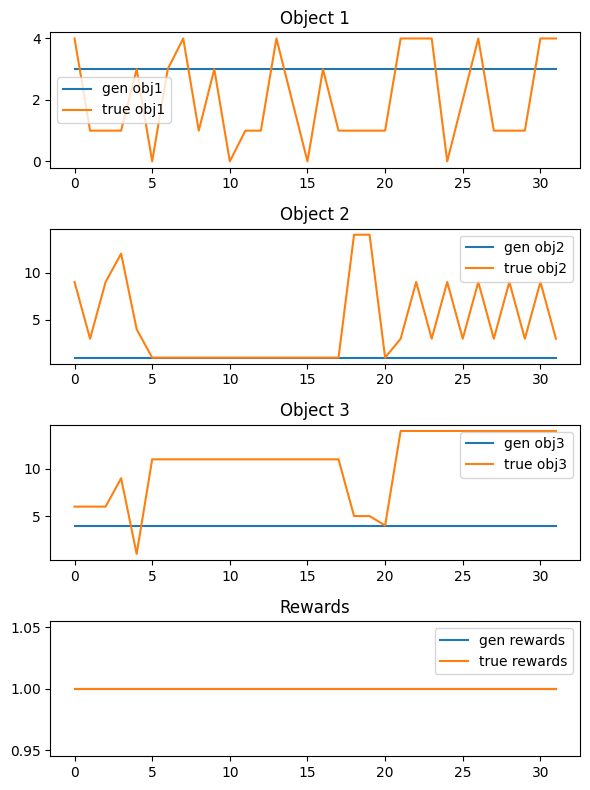

1.4567446


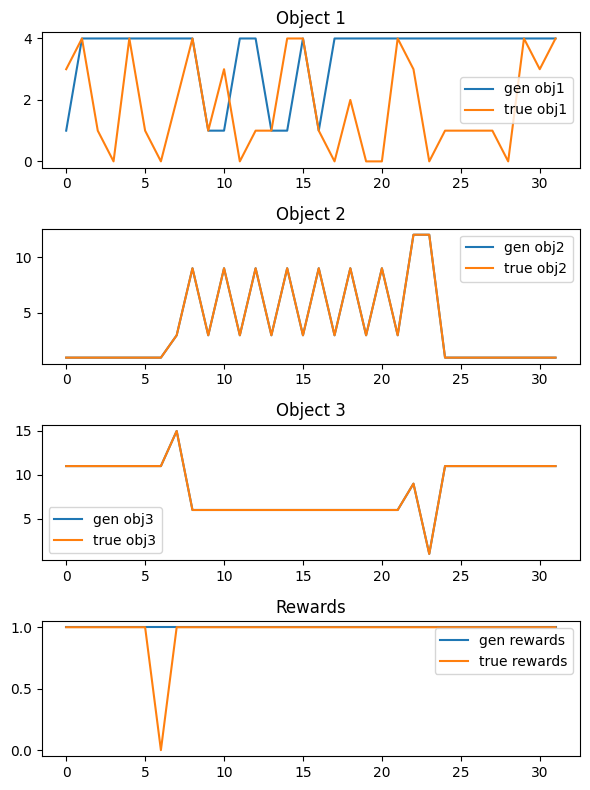

0.95305425


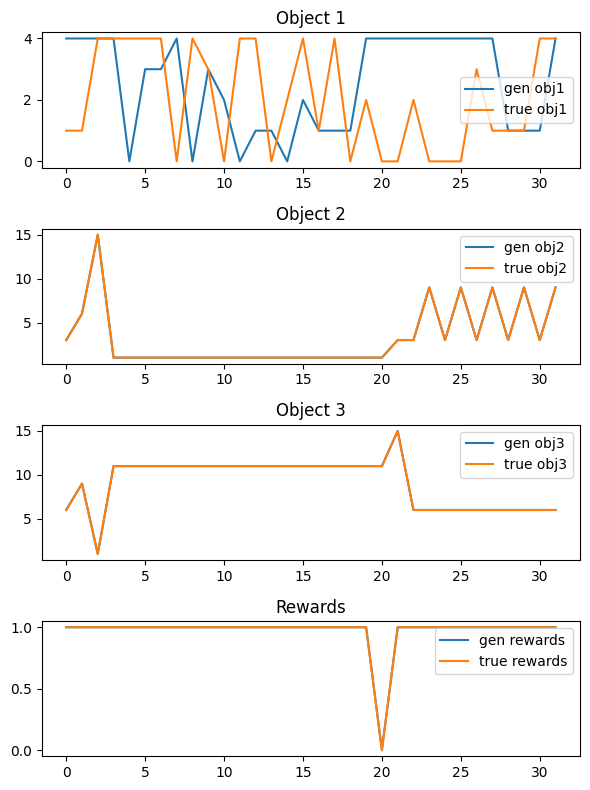

0.53678656


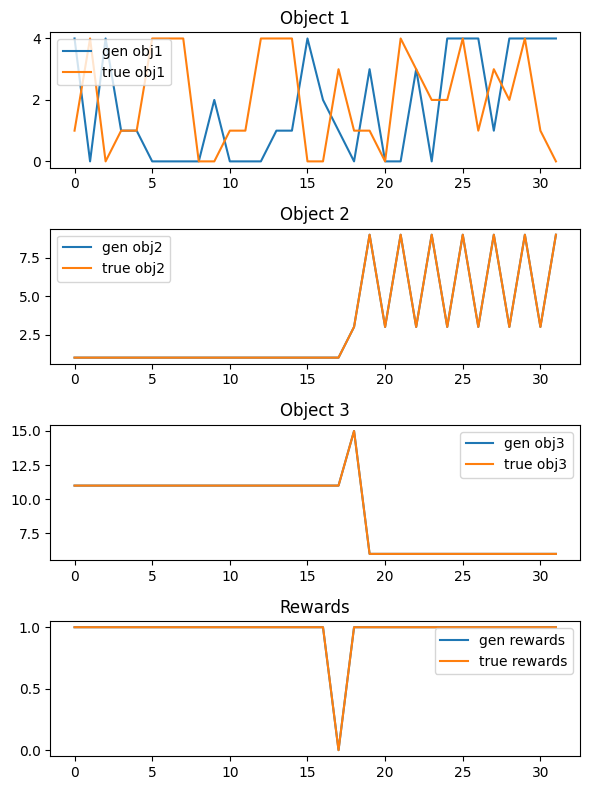

0.29750893


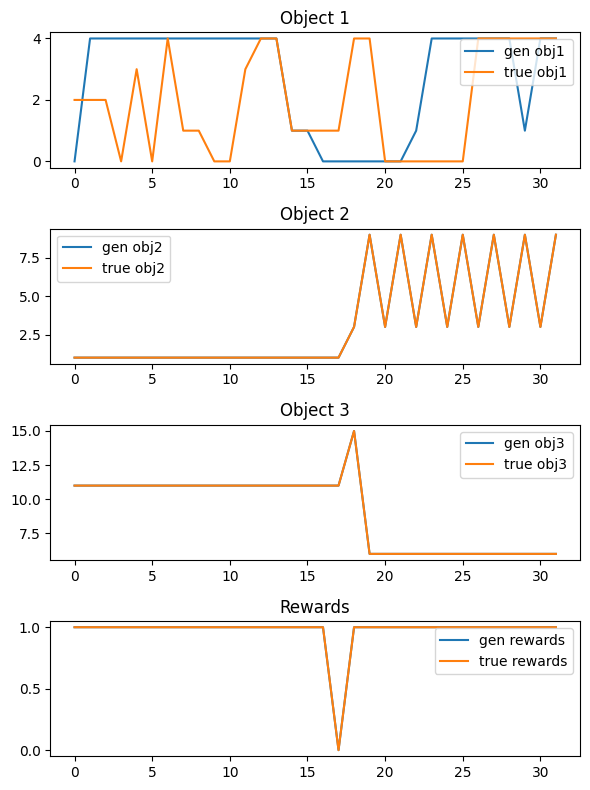

0.2321934


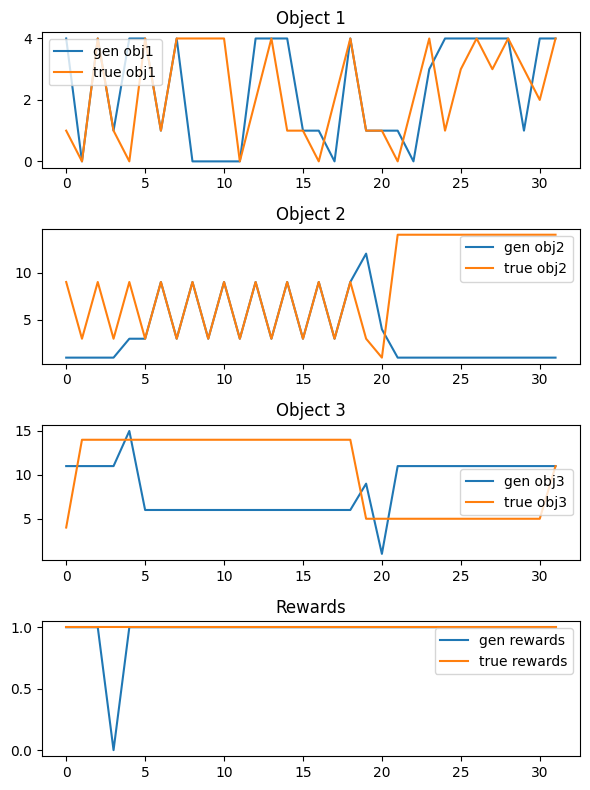

0.2046826


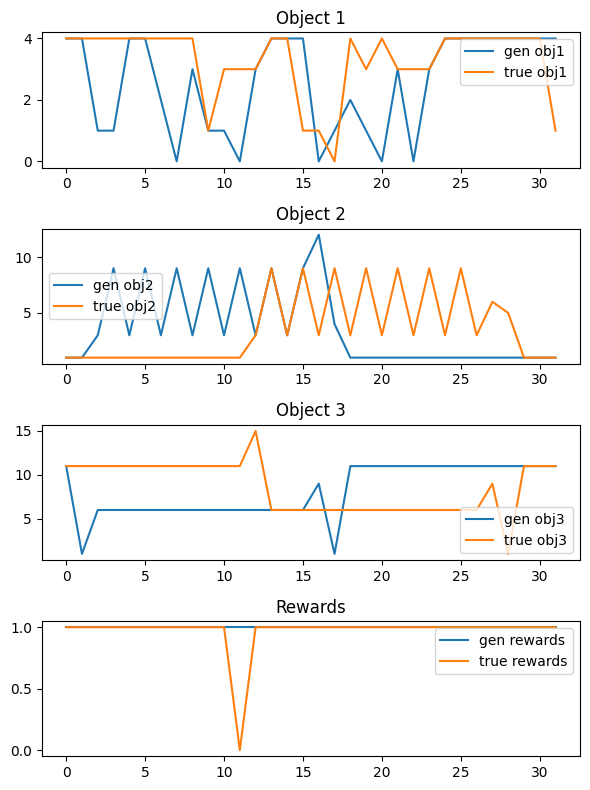

0.17082687


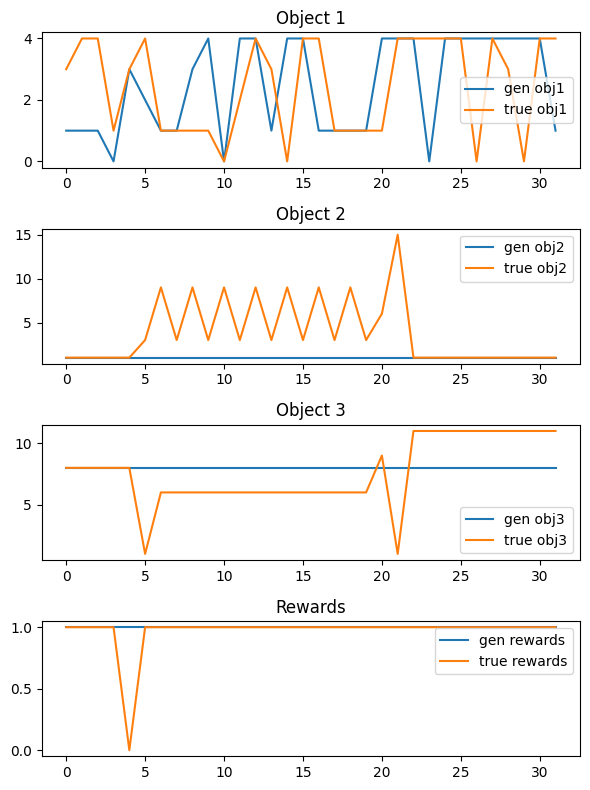

0.15298219


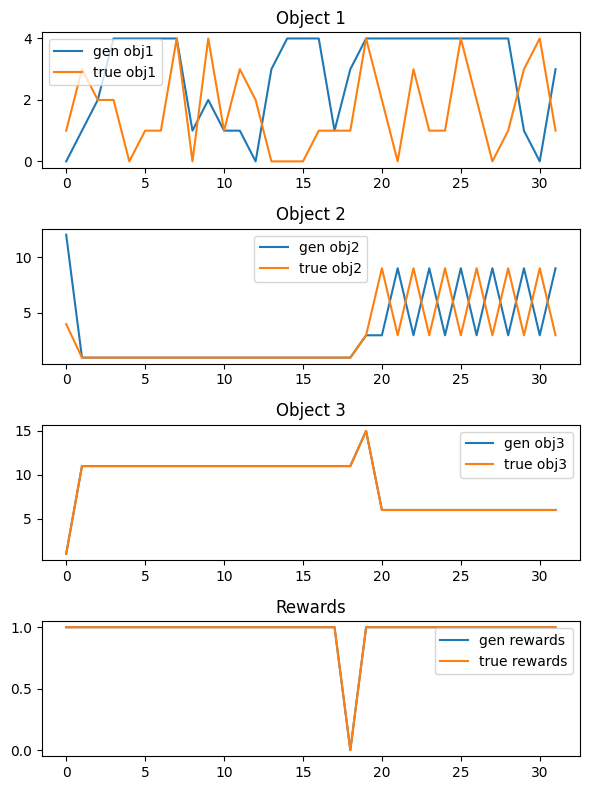

0.14113274


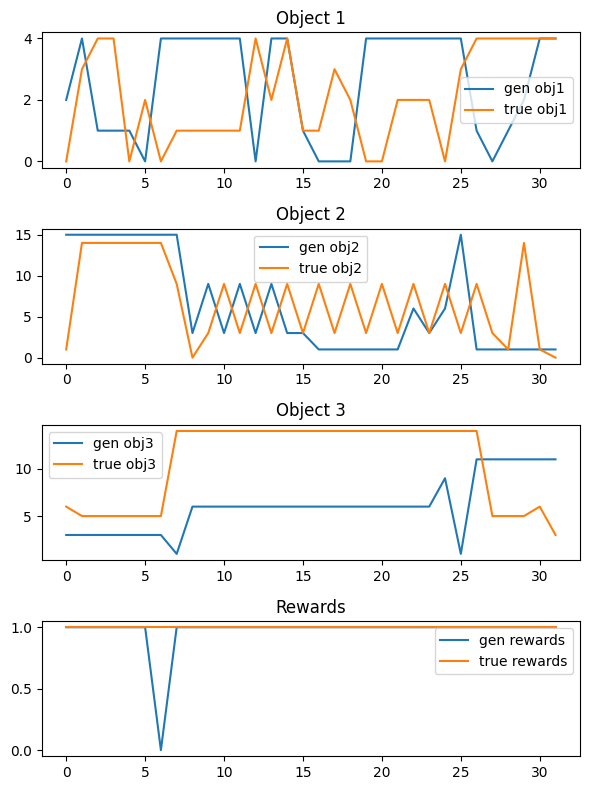

0.13408847


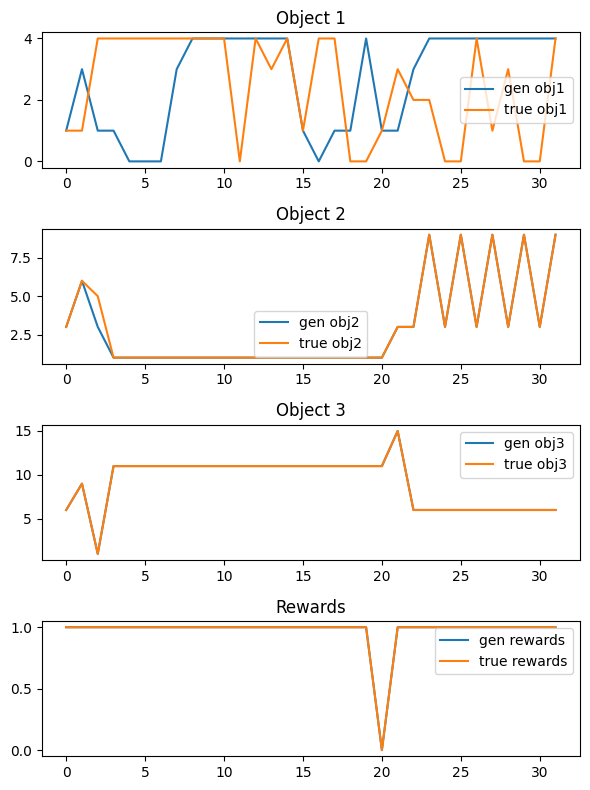

0.12903973


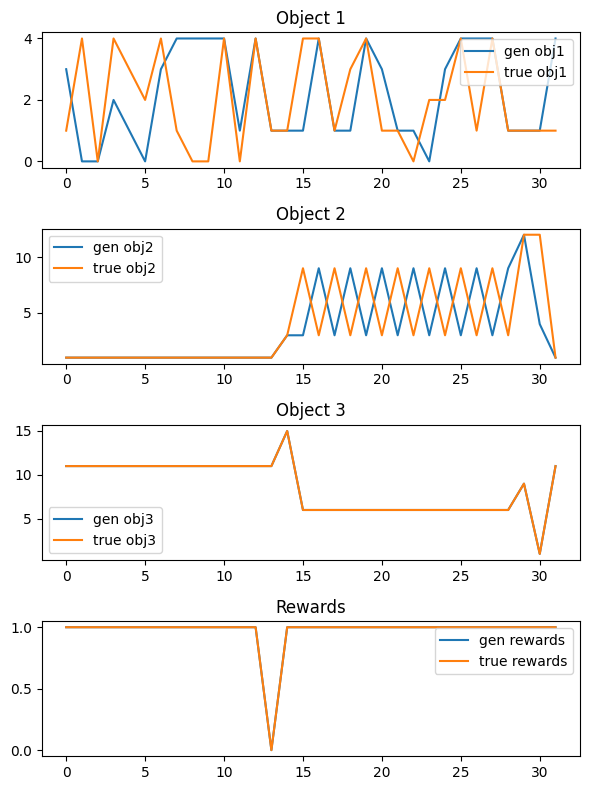

0.12195504


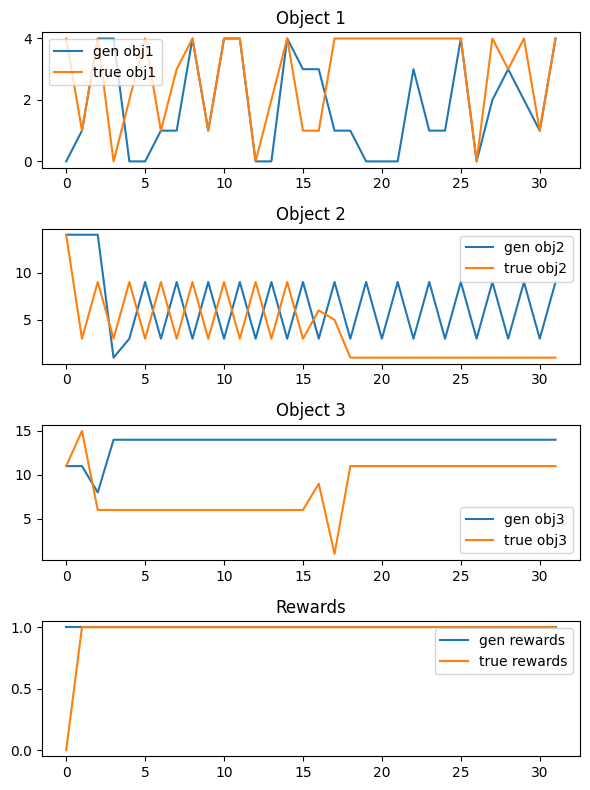

0.11120979


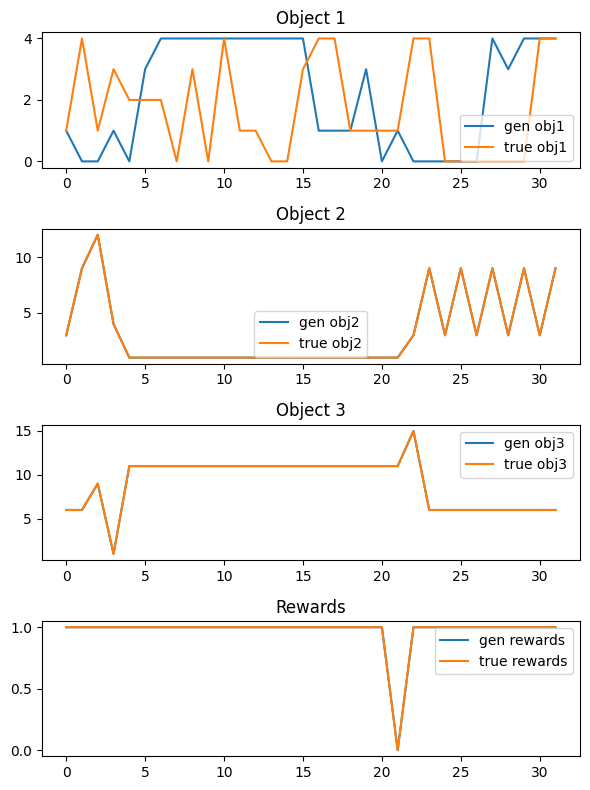

0.1181474


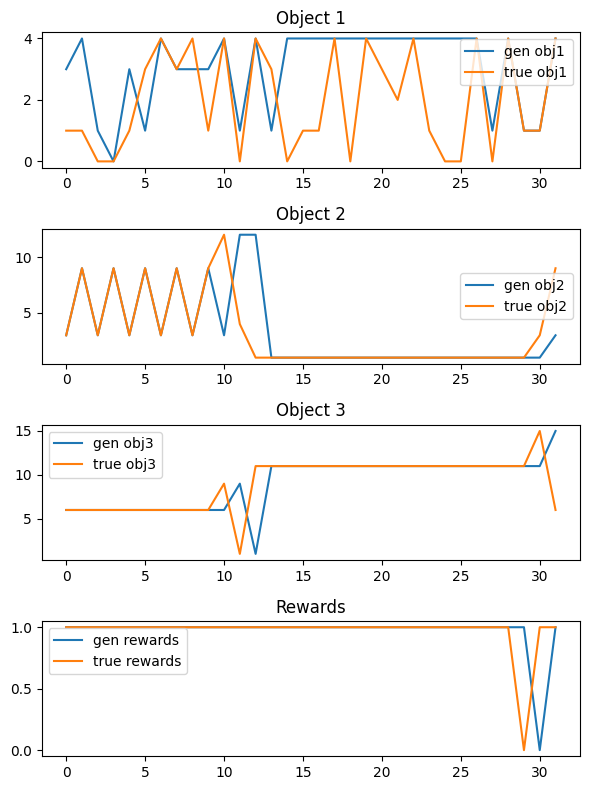

0.10290003


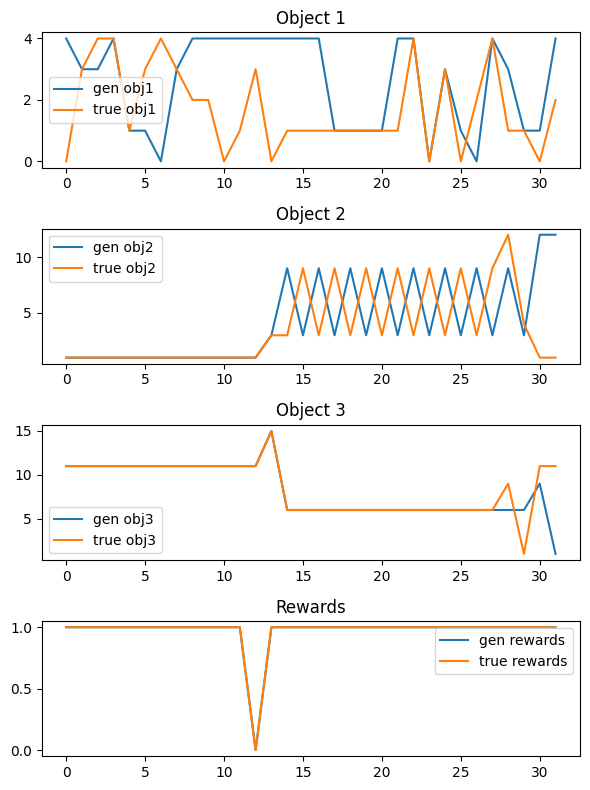

0.11520105


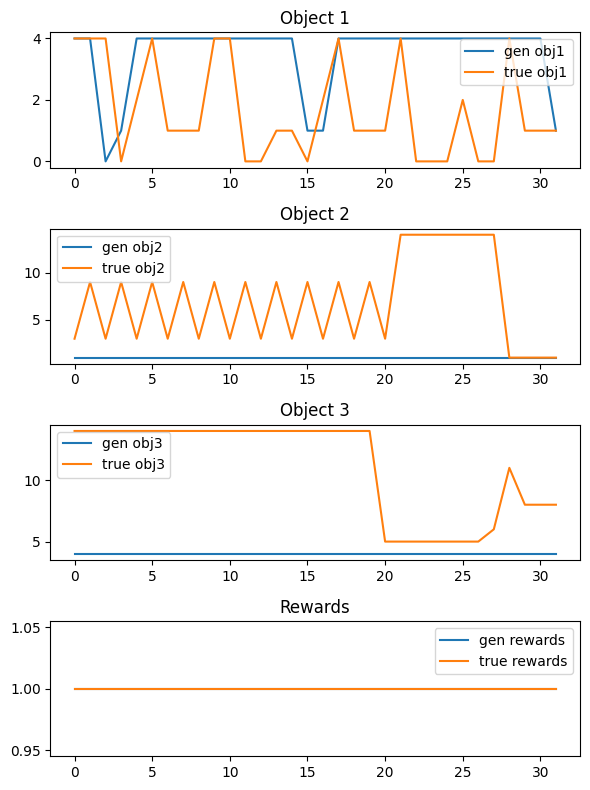

0.10563853


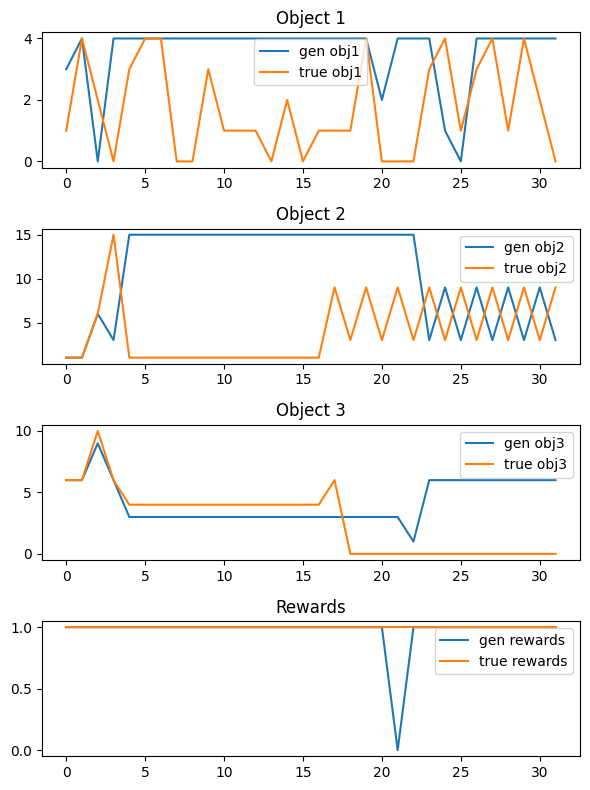

0.10599309


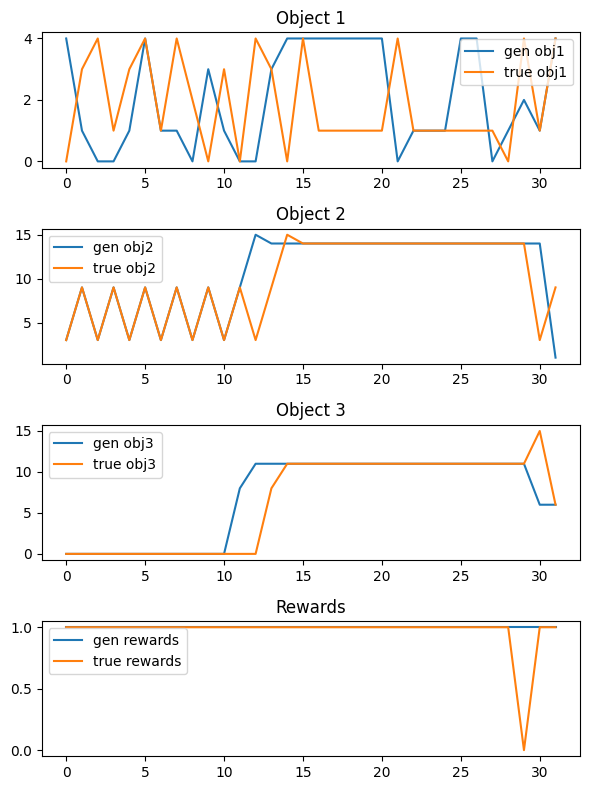

0.085614175


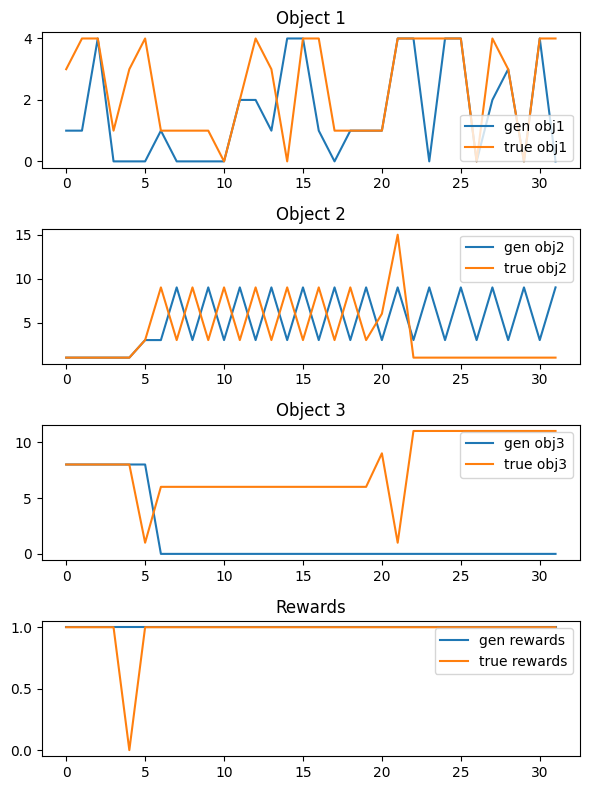

0.09603335


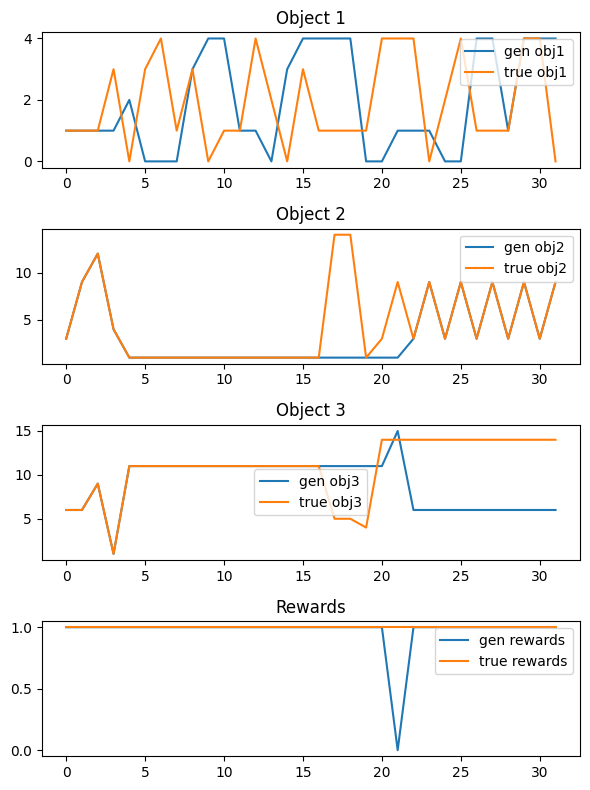

In [4]:
key = jr.PRNGKey(0)
(
    train_obj0,
    train_obj1,
    train_obj2,
    train_rewards,
    train_actions,
    test_obj1,
    test_obj2,
    test_obj3,
    test_rewards,
    test_actions,
) = load_dataset()

obj1_size = 5
obj2_size = 16
obj3_size = 16
reward_size = 3
action_size = 3

model = utils.init(
    key,
    object1_size=obj1_size,
    object2_size=obj2_size,
    object3_size=obj3_size,
    action_size=action_size,
    reward_size=reward_size,
    embed_dim_per_field=32,
    hidden_size=256,
    num_layers=10,
    num_heads=4,
    num_key_value_heads=4,
    rope_theta=10000.0,
    rms_norm_eps=1e-6,
)


def eval_callback(model, loss):
    print(loss)
    evaluate(
        model,
        test_obj1,
        test_obj2,
        test_obj3,
        test_actions,
        test_rewards,
        obj1_size,
        obj2_size,
        obj3_size,
        reward_size,
        context_len=64,
        max_tokens=64,
    )


batch_size = 64
seq_len = 128 
model = train_model(
    model,
    train_obj0,
    train_obj1,
    train_obj2,
    train_rewards,
    train_actions,
    obj1_size,
    obj2_size,
    obj3_size,
    reward_size,
    seq_len,
    batch_size,
    eval_callback,
    epochs=10000
)